In [33]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import io

# Load vital signs dataset
file_path = '/content/drive/MyDrive/human_vital_signs_dataset_2024.csv'
df = pd.read_csv(file_path)


# Identify available signals
for col in df.columns:
    print(col, end='; ')


Patient ID; Heart Rate; Respiratory Rate; Timestamp; Body Temperature; Oxygen Saturation; Systolic Blood Pressure; Diastolic Blood Pressure; Age; Gender; Weight (kg); Height (m); Derived_HRV; Derived_Pulse_Pressure; Derived_BMI; Derived_MAP; Risk Category; 

In [34]:
# Identify available signals
vital_signs = [
    "Heart Rate",
    "Respiratory Rate",
    "Oxygen Saturation",
    "Body Temperature",
    "Systolic Blood Pressure",
    "Diastolic Blood Pressure"
]

patient_info = [
    "Patient ID",
    "Age",
    "Gender",
    "Weight",
    "Height"
]

derived_signals = [
    "Derived_Pulse_Pressure",
    "Derived_BMI",
    "Derived_MAP"
]

time = ["Timestamp"]
risk_category = ["Risk Category"]

In [35]:
# Inspect data frequency and time range
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print("\n Time range:", df["Timestamp"].min(), "to", df["Timestamp"].max())
print("\n Data frequency:", df["Timestamp"].diff().mean())


 Time range: 2024-03-03 00:14:46.246950 to 2024-07-19 21:53:45.729841

 Data frequency: -1 days +23:59:00.000002586


In [36]:
# Check for missing values and data quality
print(df.isnull().sum())

# Check data types
print(df.dtypes)

# Check value ranges
print("Heart Rate < 40:", (df["Heart Rate"] < 40).sum())
print("Heart Rate > 150:", (df["Heart Rate"] > 150).sum())
print("Body Temperature < 35:", (df["Body Temperature"] < 35).sum())
print("Body Temperature > 42:", (df["Body Temperature"] > 42).sum())
print("Oxygen Saturation < 85:", (df["Oxygen Saturation"] < 85).sum())
print("Oxygen Saturation > 100:", (df["Oxygen Saturation"] > 100).sum())

### The data quality is very good because it has no missing values ​​and all the data is within the valid range

Patient ID                  0
Heart Rate                  0
Respiratory Rate            0
Timestamp                   0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
dtype: int64
Patient ID                           int64
Heart Rate                           int64
Respiratory Rate                     int64
Timestamp                   datetime64[ns]
Body Temperature                   float64
Oxygen Saturation                  float64
Systolic Blood Pressure              int64
Diastolic Blood Pressure             int64
Age                                  int64
Gender                              object
Weight (kg)                        float64
Heig

het phan 1

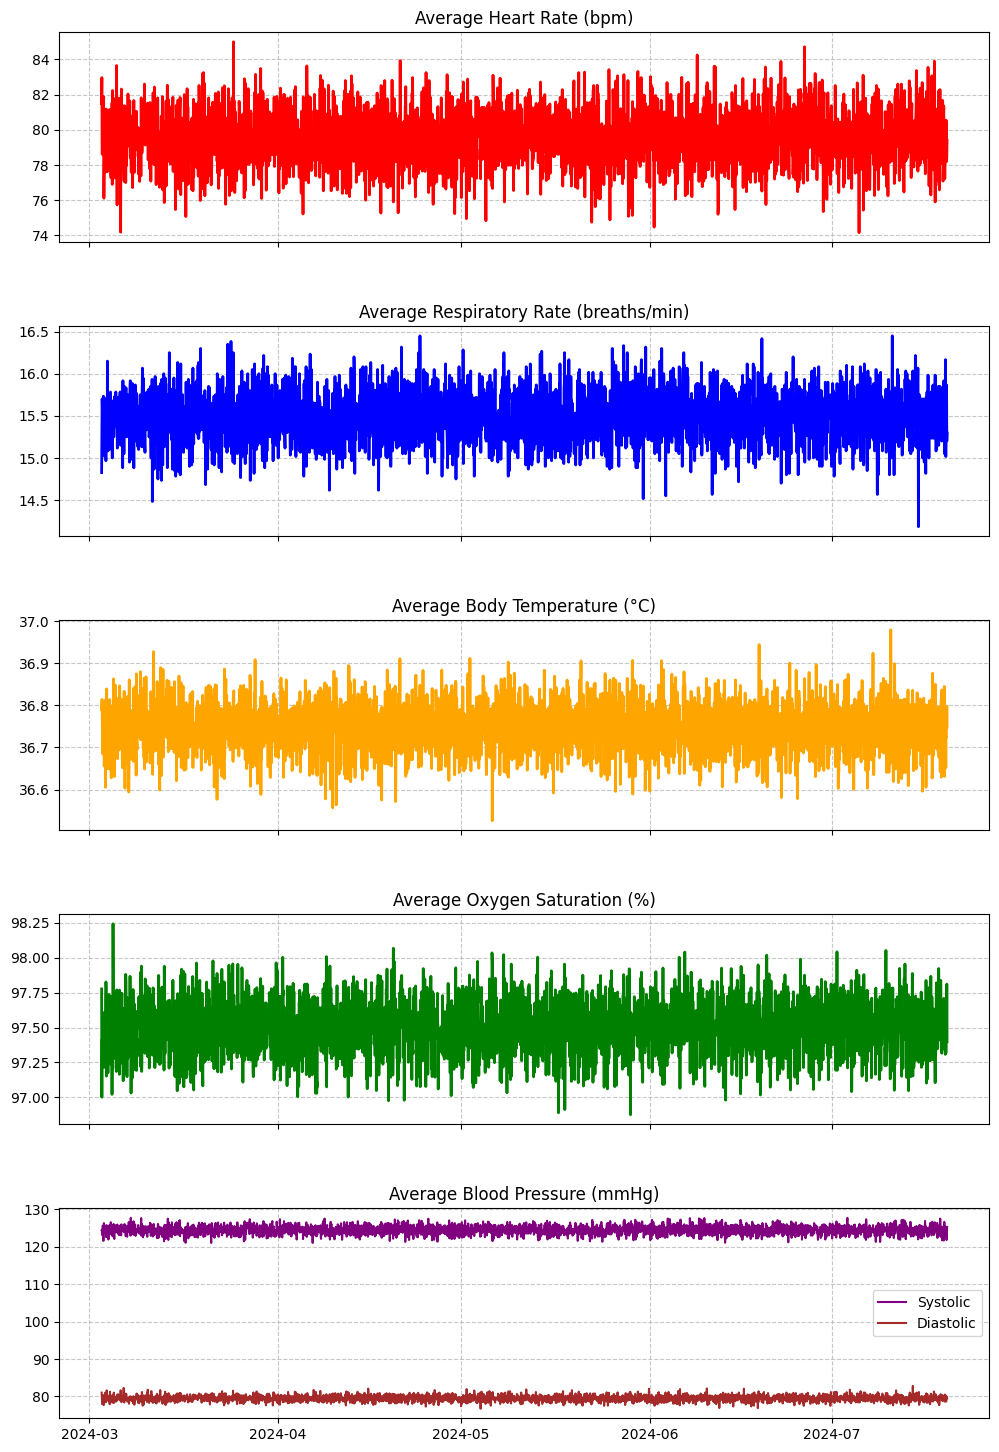

In [37]:
# Plot each vital sign over time
# Sort data by time
df = df.sort_values('Timestamp')

# Calculate the hourly average (Resampling)
df.set_index('Timestamp', inplace=True)
df_hourly = df.resample('h').mean(numeric_only=True)


# Initialize the framework with 5 subcharts.
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 18), sharex=True)
plt.subplots_adjust(hspace=0.4)

# Heart Rate
axes[0].plot(df_hourly.index, df_hourly['Heart Rate'], color='red', linewidth=2)
axes[0].set_title('Average Heart Rate (bpm)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Respiratory Rate
axes[1].plot(df_hourly.index, df_hourly['Respiratory Rate'], color='blue', linewidth=2)
axes[1].set_title('Average Respiratory Rate (breaths/min)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Body Temperature
axes[2].plot(df_hourly.index, df_hourly['Body Temperature'], color='orange', linewidth=2)
axes[2].set_title('Average Body Temperature (°C)')
axes[2].grid(True, linestyle='--', alpha=0.7)

# SpO2
axes[3].plot(df_hourly.index, df_hourly['Oxygen Saturation'], color='green', linewidth=2)
axes[3].set_title('Average Oxygen Saturation (%)')
axes[3].grid(True, linestyle='--', alpha=0.7)

# Blood Pressure (Systolic Blood Pressure and Diastolic Blood Pressure)
axes[4].plot(df_hourly.index, df_hourly['Systolic Blood Pressure'], label='Systolic', color='purple')
axes[4].plot(df_hourly.index, df_hourly['Diastolic Blood Pressure'], label='Diastolic', color='brown')
axes[4].set_title('Average Blood Pressure (mmHg)')
axes[4].legend()
axes[4].grid(True, linestyle='--', alpha=0.7)

# Show chart
plt.show()

In [38]:
# Aggregating the Biorhythm Average
if df.index.name == 'Timestamp':
    df.reset_index(inplace=True)

df['Hour_of_Day'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.day_name()

daily_biorhythm_avg = df.groupby('Hour_of_Day')[vital_signs].mean()
print(daily_biorhythm_avg.head())

             Heart Rate  Respiratory Rate  Oxygen Saturation  \
Hour_of_Day                                                    
0             79.431780         15.515374          97.489686   
1             79.668945         15.540168          97.507935   
2             79.273621         15.473861          97.493297   
3             79.454436         15.480695          97.507766   
4             79.614868         15.478537          97.514147   

             Body Temperature  Systolic Blood Pressure  \
Hour_of_Day                                              
0                   36.751884               124.431540   
1                   36.745112               124.498201   
2                   36.753940               124.307074   
3                   36.753141               124.501199   
4                   36.745984               124.484173   

             Diastolic Blood Pressure  
Hour_of_Day                            
0                           79.434182  
1                       

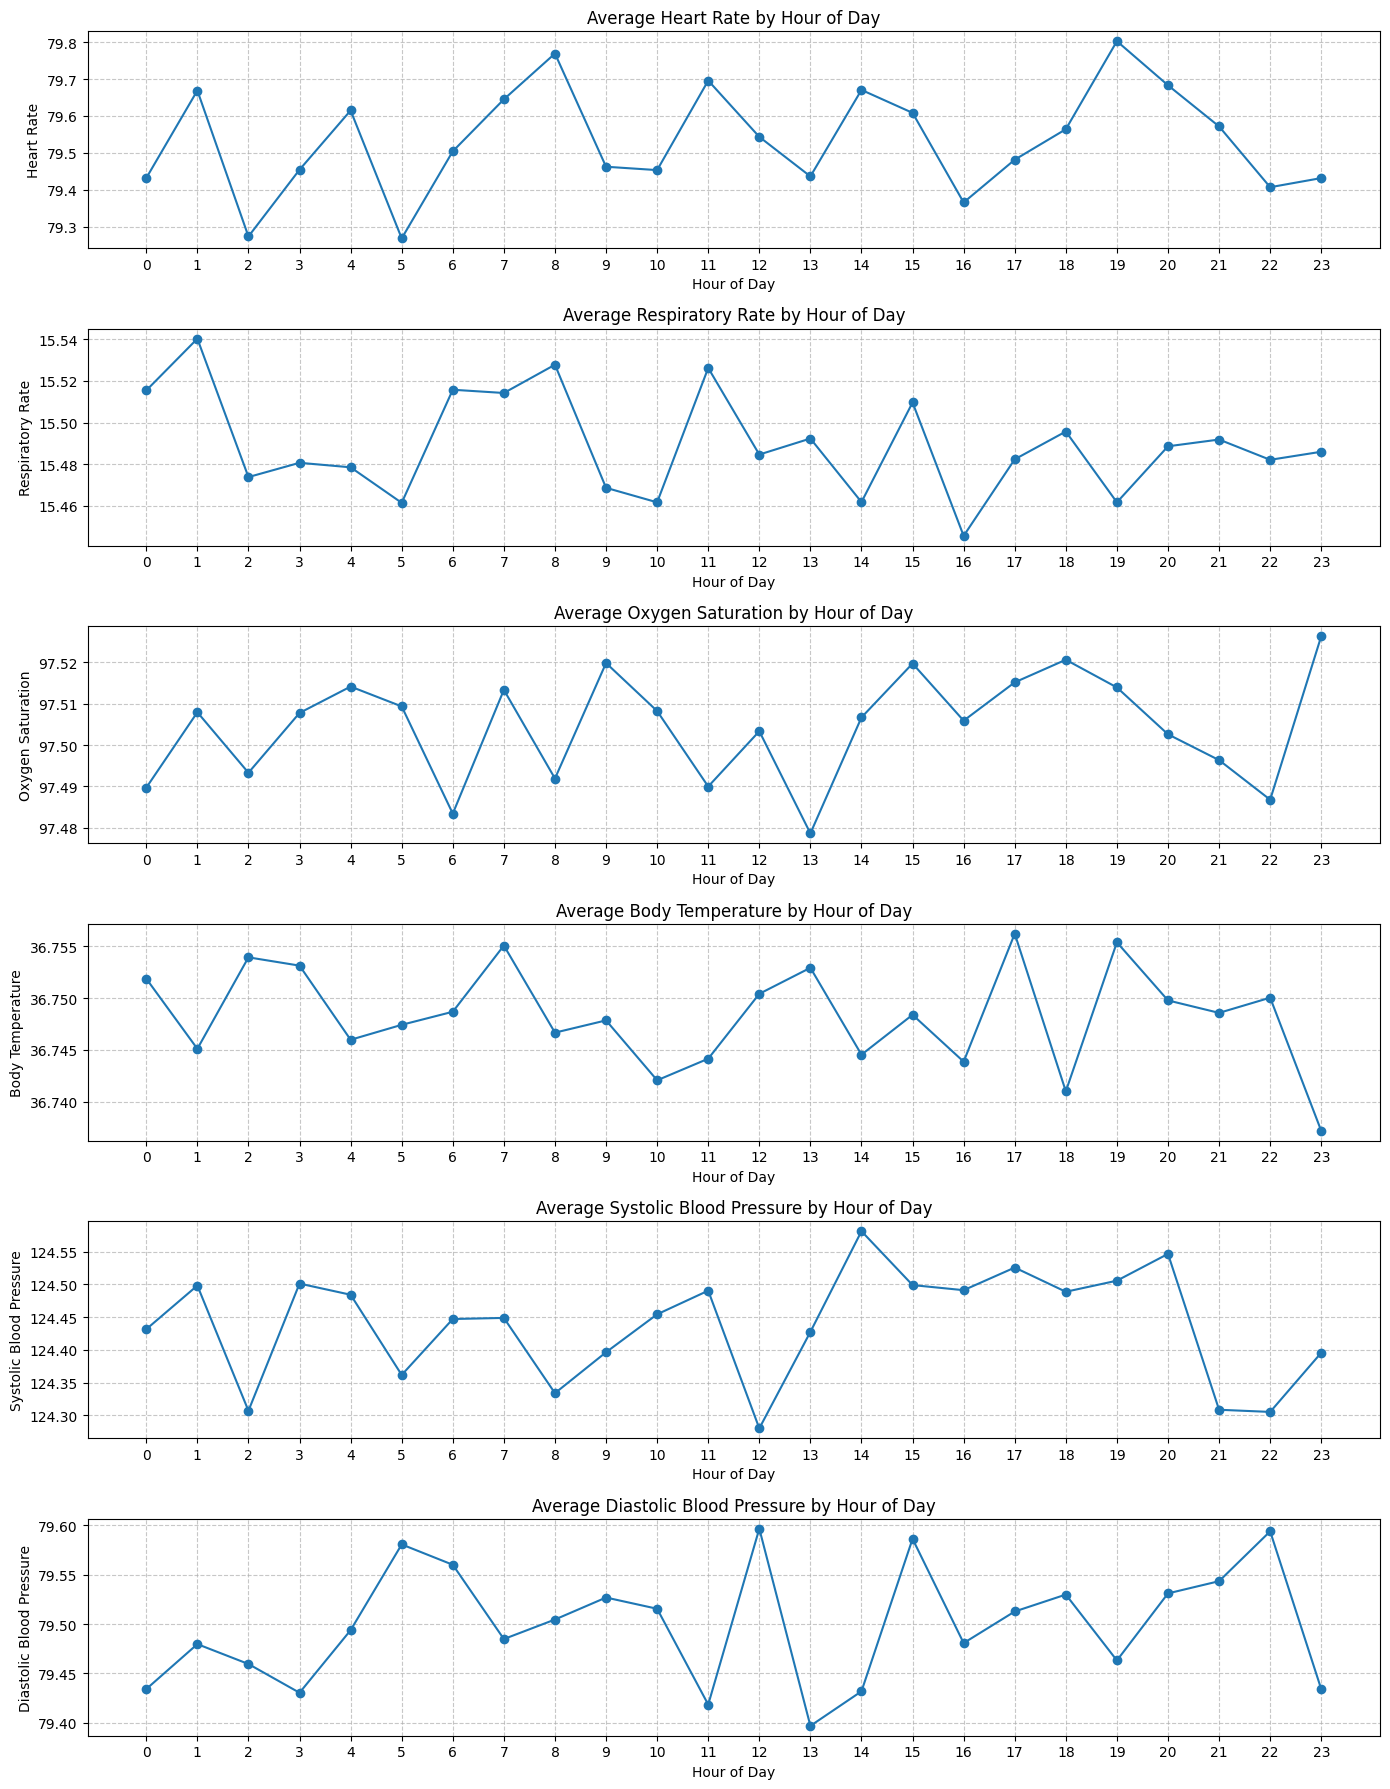

In [39]:
# Plot avg vital signs by Hour of Day
plt.figure(figsize=(14, 18))
for i, vital_sign in enumerate(vital_signs):
    plt.subplot(len(vital_signs), 1, i + 1)
    plt.plot(daily_biorhythm_avg.index, daily_biorhythm_avg[vital_sign], marker='o', linestyle='-')
    plt.title(f'Average {vital_sign} by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel(vital_sign)
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [40]:
# Mean, std, min, max
vital_signs_stats = df[vital_signs].agg(['mean', 'std', 'min', 'max'])
print("Descriptive statistics for vital signs:")
display(vital_signs_stats.round(2))

Descriptive statistics for vital signs:


,Heart Rate,Respiratory Rate,Oxygen Saturation,Body Temperature,Systolic Blood Pressure,Diastolic Blood Pressure
mean,79.53,15.49,97.50,36.75,124.44,79.50
std,11.55,2.29,1.44,0.43,8.66,5.76
min,60.00,12.00,95.00,36.00,110.00,70.00
max,99.00,19.00,100.00,37.50,139.00,89.00


In [41]:
# Check stationarity
from statsmodels.tsa.stattools import adfuller
adf_results = {}
for vital_sign in vital_signs:
      adf_test = adfuller(df_hourly[vital_sign])
      adf_results[vital_sign] = {
        'Test Statistic': adf_test[0],
        'p-value': adf_test[1],
        'Lag used': adf_test[2],
        'Number of observations used': adf_test[3],
        'Critical Values': adf_test[4]
        }
for vital_sign, results in adf_results.items():
    print(f"\n  Vital Sign: {vital_sign}")
    print(f"  Test Statistic: {results['Test Statistic']:.4f}")
    print(f"  p-value: {results['p-value']:.4e}")
    print(f"  Lag used: {results['Lag used']}")
    print(f"  Number of observations used: {results['Number of observations used']}")
    print("  Critical Values:")
    for key, value in results['Critical Values'].items():
        print(f"    {key}: {value:.4f}")



  Vital Sign: Heart Rate
  Test Statistic: -55.9303
  p-value: 0.0000e+00
  Lag used: 0
  Number of observations used: 3333
  Critical Values:
    1%: -3.4323
    5%: -2.8624
    10%: -2.5672

  Vital Sign: Respiratory Rate
  Test Statistic: -35.0475
  p-value: 0.0000e+00
  Lag used: 2
  Number of observations used: 3331
  Critical Values:
    1%: -3.4323
    5%: -2.8624
    10%: -2.5672

  Vital Sign: Oxygen Saturation
  Test Statistic: -57.5568
  p-value: 0.0000e+00
  Lag used: 0
  Number of observations used: 3333
  Critical Values:
    1%: -3.4323
    5%: -2.8624
    10%: -2.5672

  Vital Sign: Body Temperature
  Test Statistic: -42.5945
  p-value: 0.0000e+00
  Lag used: 1
  Number of observations used: 3332
  Critical Values:
    1%: -3.4323
    5%: -2.8624
    10%: -2.5672

  Vital Sign: Systolic Blood Pressure
  Test Statistic: -58.6600
  p-value: 0.0000e+00
  Lag used: 0
  Number of observations used: 3333
  Critical Values:
    1%: -3.4323
    5%: -2.8624
    10%: -2.5672

  

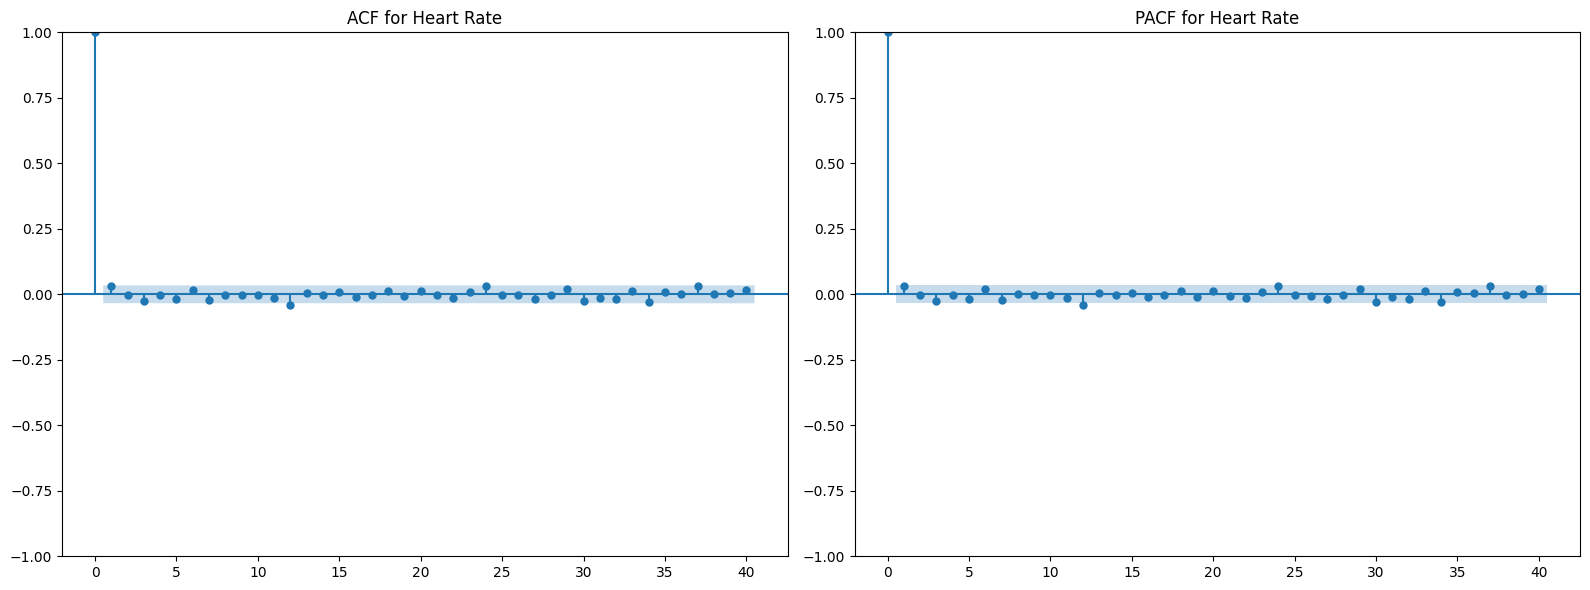

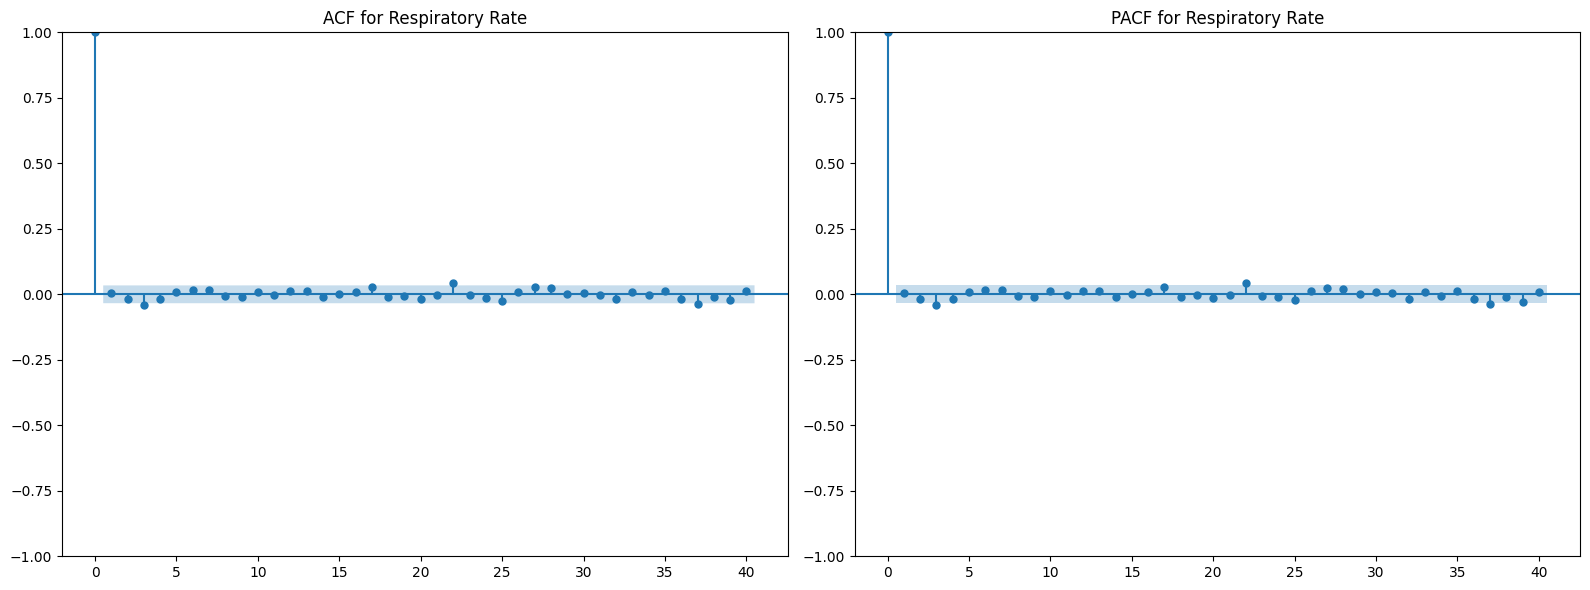

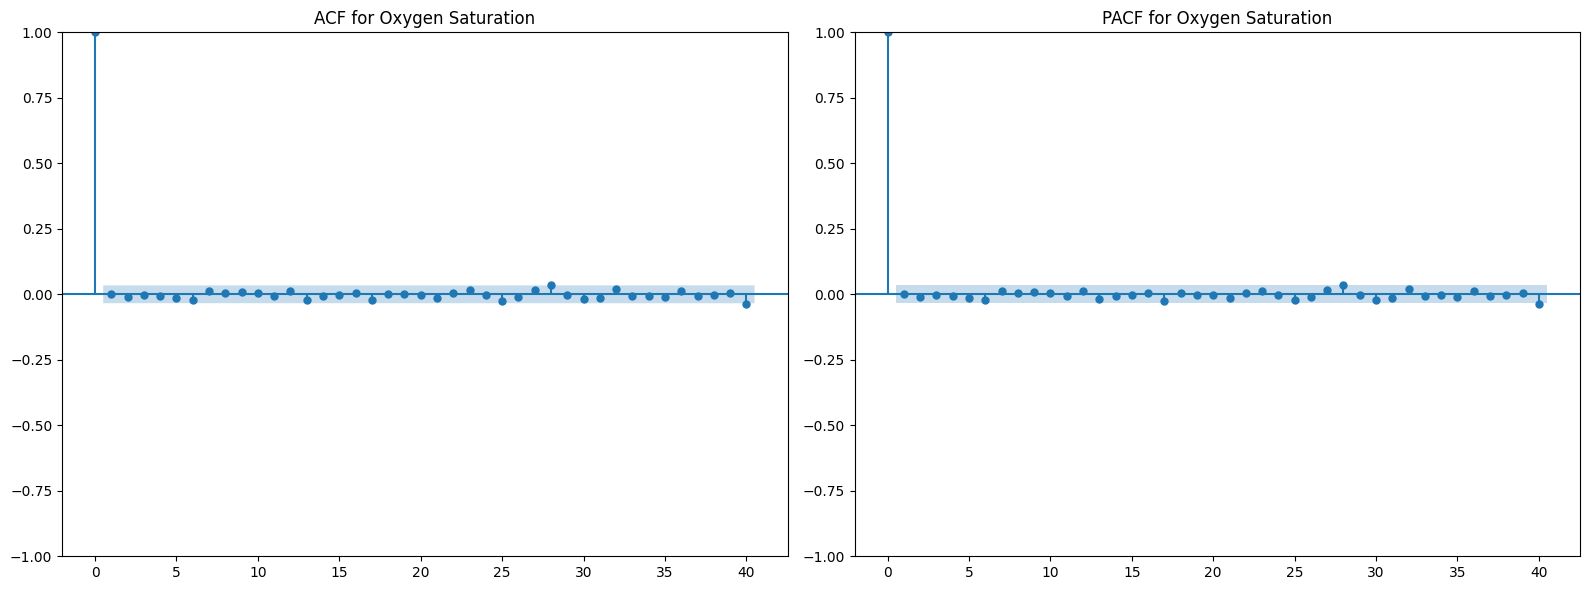

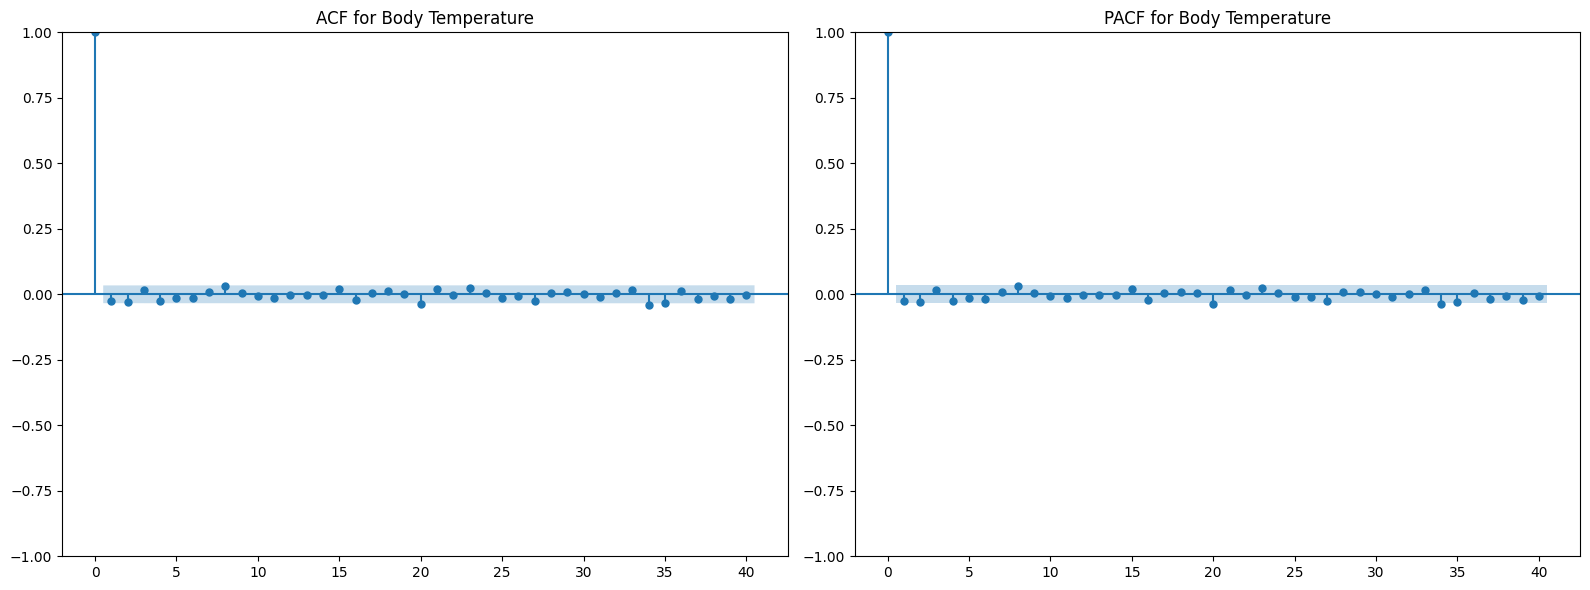

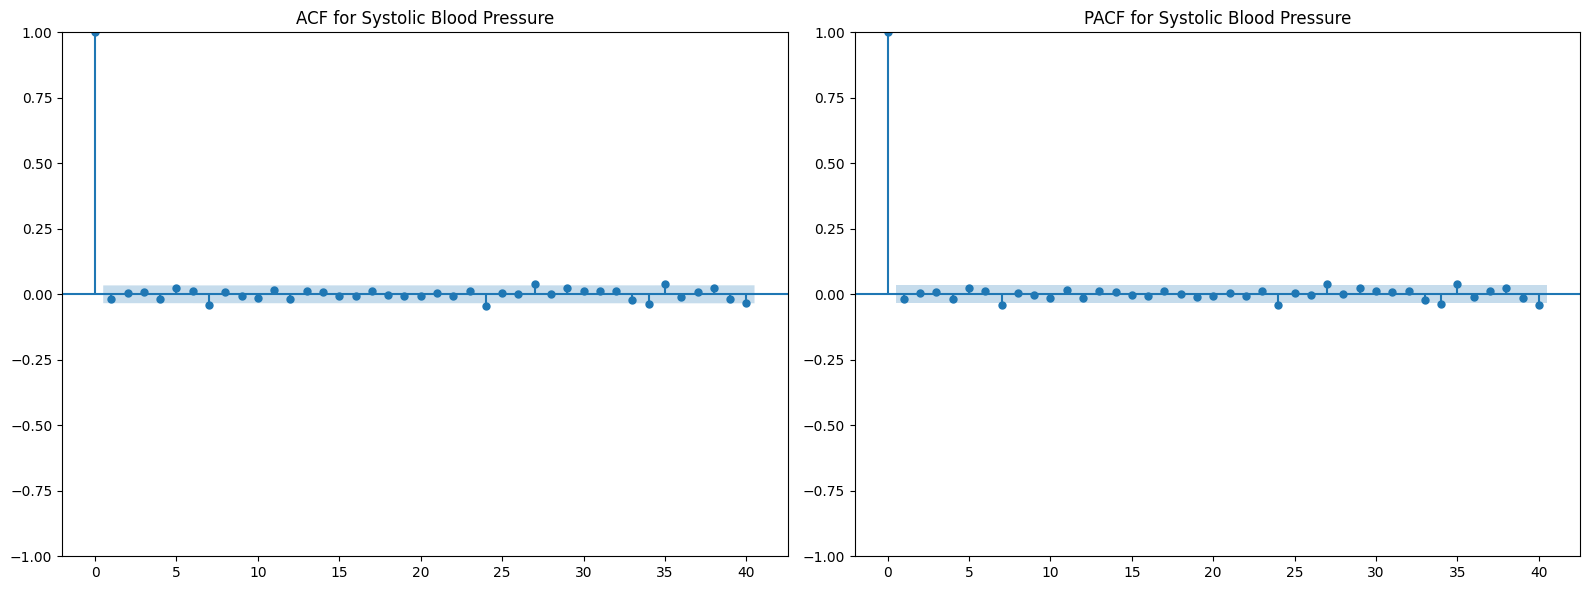

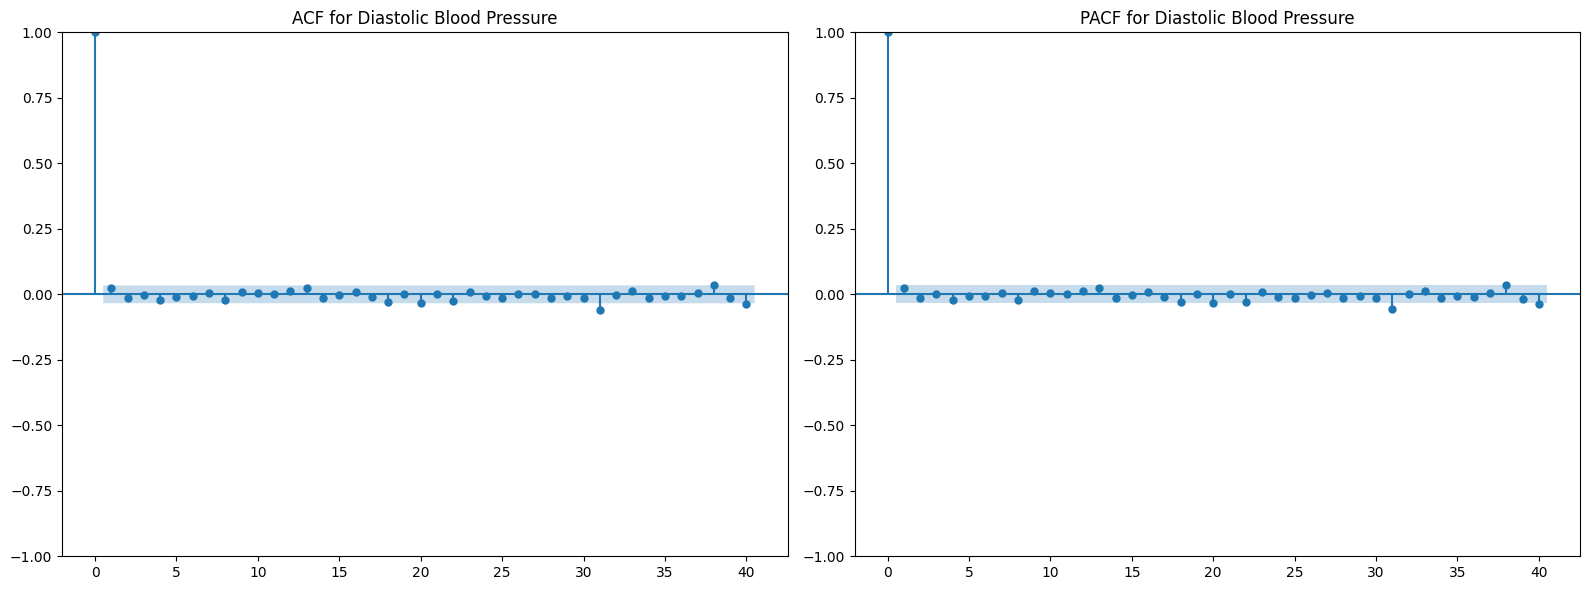

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for vital_sign in vital_signs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot ACF
    plot_acf(df_hourly[vital_sign], ax=axes[0], lags=40)
    axes[0].set_title(f'ACF for {vital_sign}')

    # Plot PACF
    plot_pacf(df_hourly[vital_sign], ax=axes[1], lags=40)
    axes[1].set_title(f'PACF for {vital_sign}')

    plt.tight_layout()
    plt.show()

In [43]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
pip install pmdarima

In [45]:
results_arima = {}

for sign in vital_signs:
    print(f"\nFitting ARIMA for {sign}")

    split = int(len(df_hourly[sign]) * 0.8)
    train = df_hourly[sign][:split]
    test = df_hourly[sign][split:]

    model_auto_arima = auto_arima(train, seasonal=False, suppress_warnings=True, stepwise=True, trace=True, error_action="ignore")

    forecast = model_auto_arima.predict(n_periods=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)

    results_arima[sign] = {
        'AIC': model_auto_arima.aic(),
        'RMSE': rmse,
        'MAE': mae
    }

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")


Fitting ARIMA for Heart Rate
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=6.80 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=30913.076, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=27369.450, Time=1.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=7.96 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=24364.551, Time=4.70 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9839.096, Time=1.32 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=12.03 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=22118.003, Time=4.01 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=9854.896, Time=0.42 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=5.61 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=9763.797, Time=1.13 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=9761.826, Time=0.55 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9759.915, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[0]

In [46]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

results_summary = {}

for sign in vital_signs:
    print(f"\nFitting SARIMA for {sign}")

    # train-test split
    split = int(len(df_hourly[sign]) * 0.8)
    train = df_hourly[sign][:split]
    test = df_hourly[sign][split:]

    # fit model
    model_auto_arima = auto_arima(train, seasonal=True, m=6, suppress_warnings=True, stepwise=True, trace=True, error_action="ignore")

    # forecast
    forecast = model_auto_arima.predict(n_periods=len(test))

    # metrics
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)

    # save results
    results_summary[sign] = {
        'AIC': model_auto_arima.aic(),
        'RMSE': rmse,
        'MAE': mae,
        'Summary': model_auto_arima.summary()
    }

    print(model_auto_arima.summary())
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")


Fitting SARIMA for Heart Rate
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[6] intercept   : AIC=10285.095, Time=28.71 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=9760.796, Time=0.14 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=11158.167, Time=15.15 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=9761.537, Time=0.80 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=30913.076, Time=0.05 sec
 ARIMA(0,0,0)(1,0,0)[6] intercept   : AIC=9763.046, Time=5.64 sec
 ARIMA(0,0,0)(0,0,1)[6] intercept   : AIC=9762.521, Time=0.51 sec
 ARIMA(0,0,0)(1,0,1)[6] intercept   : AIC=9764.523, Time=5.71 sec
 ARIMA(1,0,0)(0,0,0)[6] intercept   : AIC=9759.891, Time=0.45 sec
 ARIMA(1,0,0)(0,0,1)[6] intercept   : AIC=9761.512, Time=2.60 sec
 ARIMA(1,0,0)(1,0,1)[6] intercept   : AIC=9881.554, Time=6.71 sec
 ARIMA(2,0,0)(0,0,0)[6] intercept   : AIC=9761.872, Time=0.86 sec
 ARIMA(1,0,1)(0,0,0)[6] intercept   : AIC=9761.908, Time=1.77 sec
 ARIMA(0,0,1)(0,0,0)[6] intercept   : AIC=9759.915, Time=0.67 s

In [47]:
drop_cols = [
    "Derived_Pulse_Pressure",
    "Derived_BMI",
    "Derived_MAP",
    "Patient ID",
    "Timestamp"
]
df = df.drop(columns=drop_cols)

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def run_random_forest_classification(df, target='Risk Category', lags=3):

    data = df.copy()
    for col in df.columns:
        if col != target:
            for i in range(1, lags + 1):
                data[f'{col}_lag{i}'] = data[col].shift(i)

    data = data.dropna()

    # feature / target
    X = data.drop(columns=[target])
    X = pd.get_dummies(X, drop_first=True)
    y = data[target]

    # train/test split
    split = int(len(data) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # model
    model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    model.fit(X_train, y_train)

    # predict
    y_pred = model.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, y_pred)

    return model, y_test, y_pred, acc, X.columns


model, y_test, y_pred, acc, features = run_random_forest_classification(df)

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8766

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.98      0.78      0.87     21036
    Low Risk       0.80      0.99      0.88     18968

    accuracy                           0.88     40004
   macro avg       0.89      0.88      0.88     40004
weighted avg       0.90      0.88      0.88     40004



In [49]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(15))

                   Feature  Importance
0               Heart Rate    0.580866
7              Weight (kg)    0.209416
8               Height (m)    0.171651
37         Height (m)_lag3    0.001485
40        Derived_HRV_lag3    0.001384
9              Derived_HRV    0.001337
3        Oxygen Saturation    0.001335
33        Weight (kg)_lag2    0.001335
39        Derived_HRV_lag2    0.001334
22  Oxygen Saturation_lag3    0.001325
17   Body Temperature_lag1    0.001318
18   Body Temperature_lag2    0.001294
36         Height (m)_lag2    0.001291
35         Height (m)_lag1    0.001273
19   Body Temperature_lag3    0.001226


In [77]:
!git config --global user.name "phandang2310"
!git config --global user.email "phandang2310@gmail.com"

In [83]:
!git clone https://github.com/phandang2310/human-vital-signs.git

Cloning into 'human-vital-signs'...


In [85]:
!cp/content/drive/MyDrive/Colab Notebooks/human_vital_signs_dataset.ipynb /content/human-vital-signs/

/bin/bash: line 1: cp/content/drive/MyDrive/Colab: No such file or directory
